# **Maestría en Inteligencia Artificial Aplicada**
## **Curso: Procesamiento de Lenguaje Natural (NLP)**
### Tecnológico de Monterrey
### Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

### **Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre:** Isaac Carballo Perez

* **matrícula:** A01796987
  

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

from matplotlib import pyplot as plt

In [2]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## **Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**

Un **falso negativo** ocurre cuando el modelo clasifica como negativa una reseña que en realidad era positiva. Este problema implicaría subestimar la satisfacción del usuario: por ejemplo, se podría perder evidencia de productos, películas o servicios que sí fueron bien evaluados, o tomar decisiones innecesariamente pesimistas sobre ellos.

Un **falso positivo** ocurre cuando el modelo clasifica como positiva una reseña que en realidad era negativa. Este error oculta señales de insatisfacción: una queja sobre un producto, una mala experiencia en un restaurante o una opinión negativa sobre una película podría interpretarse como aprobación, reduciendo la probabilidad de corregir el problema.

En este contexto, ambos errores son importantes, pero consideraría más grave el **falso positivo** si el objetivo práctico es detectar inconformidad y mejorar la calidad del servicio o producto. Clasificar una reseña negativa como positiva puede llevar a ignorar problemas reales. 

Sin embargo, si el objetivo fuera medir aceptación general o seleccionar reseñas para promoción, los falsos negativos también tendrían un costo relevante porque descartarían opiniones positivas útiles.

##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################


Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [3]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [4]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

### **Cargamos los datos del problema:**

In [5]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv('./sentiment_labelled_sentences/amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('./sentiment_labelled_sentences/imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('./sentiment_labelled_sentences/yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [6]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
# uno con los comentarios (review) y otro con la etiqueta (label).
# Por ejemplo, mostremos a continuación los primeros comentarios
# y etiquetas del archivo de Amazon:


,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [7]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

## **Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [8]:
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.


################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:

patron_registro = r'(.+?)\t([01])(?:\r?\n|$)'

# El patrón se interpreta por partes:
# (.+?) captura el comentario de forma no codiciosa, es decir, se detiene
#       en la primera etiqueta válida que encuentre.
# \t    identifica el tabulador que separa la reseña de su etiqueta.
# ([01]) captura la etiqueta binaria: 0 para negativa y 1 para positiva.
# (?:\r?\n|$) marca el final del registro, ya sea salto de línea o fin del texto.
# re.DOTALL permite revisar también los registros que pandas juntó en varias líneas.

for _, row in dfi.iterrows():
    # Reconstruye la fila como una sola string de texto plano.
    # Esto es necesario porque debido a error de captura varias reseñas terminaron en una sola celda
    #
    # Ejemplo de lo que pandas entrega en una fila:
    #   row['review'] = "Great acting\ntruly wonderful\t1\nTerrible film\t0\nAmazing cast"
    #   row['label']  = 1
    #
    # texto_fila resultante:
    #   "Great acting\ntruly wonderful\t1\nTerrible film\t0\nAmazing cast\t1"
    #    ↑ aquí ya están todos los pares reseña\tetiqueta fusionados en una sola string
    #    el \t1 del final solo completa la cadena
    texto_fila = f"{row['review']}\t{int(row['label'])}"

    # Busca todos los pares (reseña, etiqueta) dentro de `texto_fila`.
    #
    # Se utiliza `re.DOTALL` porque algunas reseñas contienen saltos de línea internos (`\n`).
    # Normalmente, el punto (`.`) en una expresión regular NO coincide con saltos de línea,
    # por lo que una reseña multilínea podría cortarse incorrectamente.
    #
    # Ejemplo:
    #
    # texto_fila = "Great acting\ntruly wonderful\t1\nTerrible film\t0\n"
    #
    # Sin `re.DOTALL`:
    # ------------------------------------------------------------
    # El regex interpreta el contenido como fragmentos separados:
    #
    #   "Great acting"
    #       → no contiene `\t0` o `\t1`
    #       → no hace match y se ignora
    #
    #   "truly wonderful\t1"
    #       → sí cumple el patrón
    #       → hace match, pero la reseña queda incompleta
    #
    #   "Terrible film\t0"
    #       → hace match correctamente
    #
    # El problema ocurre porque:
    #
    #   (.+?)
    #
    # intenta capturar texto hasta encontrar `\t0` o `\t1`, pero al llegar a `\n`
    # se detiene inmediatamente, ya que el punto (`.`) no puede atravesar saltos de línea.
    #
    # Entonces, el regex:
    #
    #   1. Intenta comenzar desde:
    #          "Great acting\n..."
    #      pero no logra llegar hasta `\t1`
    #      → no hay match
    #
    #   2. Continúa buscando más adelante y comienza desde:
    #          "truly wonderful\t1\n"
    #      ahora sí encuentra `\t1`
    #      → match exitoso
    #
    # Resultado sin DOTALL:
    #
    #   [
    #       ("truly wonderful", "1"),
    #       ("Terrible film", "0")
    #   ]
    #
    # Observa que:
    #   - la primera reseña quedó incompleta
    #   - se perdió "Great acting\n"
    #
    #
    # Con `re.DOTALL`:
    # ------------------------------------------------------------
    # El punto (`.`) ahora sí puede atravesar `\n`,
    # permitiendo capturar reseñas multilínea completas.
    #
    # Entonces el regex puede capturar:
    #
    #   "Great acting\ntruly wonderful\t1"
    #
    # como una sola reseña válida.
    #
    # Resultado con DOTALL:
    #
    #   [
    #       ("Great acting\ntruly wonderful", "1"),
    #       ("Terrible film", "0")
    #   ]
    #
    # De esta forma se preserva correctamente todo el contenido de la reseña,
    # incluso cuando contiene saltos de línea internos.

    registros = re.findall(patron_registro, texto_fila, flags=re.DOTALL)   # extrae los pares review/label usando el patrón, considerando también saltos de línea internos

    for review, label in registros:
        newdfi.append([review.strip(), int(label)])


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))


Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [9]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.',
  1],
 ['The structure of this film is easily the most tightly constructed in the history of cinema.',
  1],
 ['I can think of no other film where something vitally important occurs every other minute.',
  1]]

Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [10]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [11]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

# Usamos ignore_index para no reiniciar los índices en cada bloque concatenado.
df = pd.concat([dfa, dfii, dfy], ignore_index=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [12]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [13]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


## **Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [14]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Creo que en estos casos en particular se puede rescatar los reviews respetando la idea, si se busca solo mantener caracteres alfabeticos esta expresion se puede remplazar con su interpretacion con caracteres alfabeticos 10/10 se traduce en "Ten out of ten". Podemos remplazar el review invalido con esto. 



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [15]:
# Ahora separemos la información:
#     La "X" serán los datos de entrada, los comentarios.
#     La "Y" será la variable de salida, las etiquetas de la evaluación.
# Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.


## **Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [16]:
def clean_tok(doc: str) -> list[str]:
    ##############################################################################
    # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

    # Remplaza los registros previamente identificados con 10/10 con su expresion textual equivalente.
    if doc.strip() == '10/10':
        doc = 'Ten out of ten'   # Reemplazamos todas las ocurrencias de "10/10" por "Ten out of ten".

    doc = re.sub(r'[^a-zA-Z\s]', ' ', doc) # Eliminamos caracteres que no sean letras o espacios.

    doc = doc.lower()  # Convertimos el texto a minúsculas para normalizarlo.

    tokens = doc.split()  # Dividimos el texto en tokens utilizando espacios como delimitadores.

    tokens = [t for t in tokens if t not in mystopwords and len(t) > 1]  # Eliminamos las stopwords de la lista de tokens.

    # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
    ##############################################################################

    return tokens


In [17]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [18]:
for x in Xcleantok[0:5]:
    print(x)


['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


## **Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [19]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:

from nltk.stem import WordNetLemmatizer   # Lematizador basado en WordNet
from nltk.corpus import wordnet           # Diccionario WordNet

lemmatizer = WordNetLemmatizer()          # Crear instancia del lematizador

try:
    wordnet.ensure_loaded()               # Verifica si WordNet está cargado
    use_wordnet = True                    # Disponible → usarlo
except LookupError:
    nltk.download('wordnet', quiet=True)  # Descarga WordNet si falta
    try:
        wordnet.ensure_loaded()           # Reintenta cargar WordNet
        use_wordnet = True                # Disponible → usarlo
    except LookupError:
        use_wordnet = False               # No disponible → desactivar

def clean_doc(doc):
    tokens = []

    for token in doc:
        # Proceso 1: reducimos letras repetidas en exceso, por ejemplo goooood -> good.
        # Regex: (.) captura un caracter; \1{2,} busca ese mismo caracter dos o más
        # veces adicionales. Esto reduce 3+ repeticiones a 2 sin borrar énfasis útil.
        token = re.sub(r'(.)\1{2,}', r'\1\1', token)

        # Proceso 2: lematizamos de forma conservadora para conservar palabras legibles.
        # A diferencia del stemming, evita salidas como qualiti, batteri o minut.
        # No lematizamos tokens muy cortos para preservar negaciones y abreviaturas.
        if use_wordnet and len(token) > 2:
            token = lemmatizer.lemmatize(token, pos='n')
            token = lemmatizer.lemmatize(token, pos='v')

        if len(token) > 1:
            tokens.append(token)

    return tokens
    # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
    ##############################################################################


In [20]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [21]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'us', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem'],
 ['mic', 'great']]

## **Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [22]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

# Vista compacta para revisar la limpieza sin saturar la salida del notebook.
print('Primeros 10 comentarios limpios:')
for tokens in Xclean[:10]:
    print(tokens)

pt_tokens = []
nt_tokens = []

for tokens, label in zip(Xclean, y):
    if label == 1:
        pt_tokens.extend(tokens)
    else:
        nt_tokens.extend(tokens)

pt = ' '.join(pt_tokens)
nt = ' '.join(nt_tokens)

print('\nTokens positivos:', len(pt_tokens), '10 ejemplos: ', pt_tokens[:10])
print('Tokens negativos:', len(nt_tokens), '10 ejemplos: ', nt_tokens[:10])

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


Primeros 10 comentarios limpios:
['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem']
['mic', 'great']
['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume']
['several', 'dozen', 'several', 'hundred', 'contact', 'imagine', 'fun', 'send', 'one', 'one']
['razr', 'owner', 'must']
['needless', 'say', 'waste', 'money']
['waste', 'money', 'time']

Tokens positivos: 9400 10 ejemplos:  ['good', 'case', 'excellent', 'value', 'great', 'jawbone', 'mic', 'great', 'razr', 'owner']
Tokens negativos: 9267 10 ejemplos:  ['no', 'way', 'plug', 'us', 'unless', 'go', 'converter', 'tie', 'charger', 'conversation']


Text(0.5, 1.0, 'Comentarios negativos')

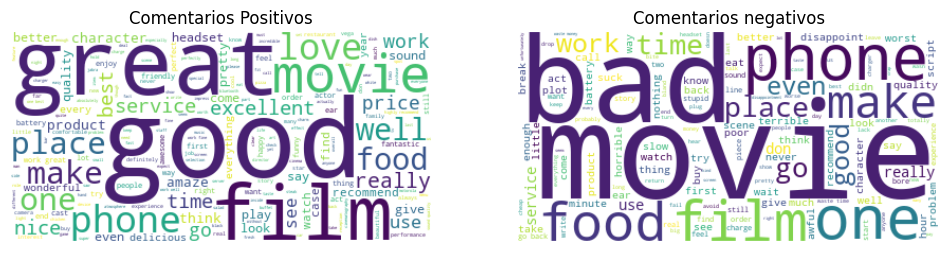

In [23]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
from wordcloud import WordCloud

wordcloud_pos = WordCloud(background_color='white', random_state=42).generate(pt)
ax1.imshow(wordcloud_pos, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Comentarios Positivos')

wordcloud_neg = WordCloud(background_color='white', random_state=42).generate(nt)
ax2.imshow(wordcloud_neg, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Comentarios negativos')


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**

En las nubes de palabras se observan términos que sí parecen asociarse con cada clase. En los comentarios positivos aparecen con mucha fuerza palabras como `great`, `good`, `love`, `best` y `excellent`, que suelen expresar satisfacción o una buena experiencia. En los comentarios negativos aparecen términos como `not`, `bad`, `no`, `don` y `waste`, que suelen relacionarse con inconformidad, rechazo o problemas.

Sin embargo, también hay muchas palabras presentes en ambas nubes, como `movie`, `phone`, `food`, `service`, `place`, `time` o `work`. Esto ocurre porque las reseñas mencionan repetidamente el objeto evaluado, no solo el sentimiento hacia ese objeto. Esas palabras ayudan a identificar el tema de la reseña, pero por sí solas no siempre permiten distinguir si la opinión es positiva o negativa.

Por eso, las nubes de palabras son útiles para una exploración inicial, pero no bastan para clasificar el sentimiento. Para una clasificación más confiable se necesita considerar la combinación de palabras, las negaciones y la frecuencia relativa de los términos dentro de cada clase.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


### **Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


### Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [25]:
from collections import Counter

In [26]:
from collections import Counter

midiccionario = Counter()                 # Inicializa un contador vacío

for k in range(len(x_train)):             # Recorre cada lista de palabras en x_train
    midiccionario.update(x_train[k])      # Actualiza el conteo con esa lista completa
                                          # Counter sabe manejar listas → suma cada palabra


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))


Longitud del diccionario: 3286

(word,frequency):
[('not', 218), ('good', 164), ('movie', 140), ('great', 138), ('phone', 134), ('film', 130), ('work', 113), ('like', 101), ('time', 101), ('one', 100)]


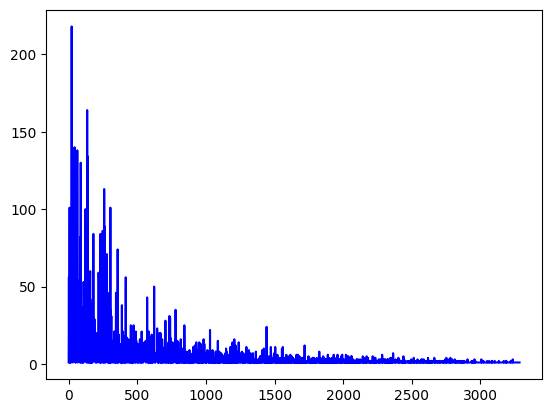

In [27]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

# Graficamos la frecuencia de los tokens del vocabulario de entrenamiento.
# El eje X no representa palabras específicas, sino la posición de cada token en el diccionario.
# El eje Y muestra cuántas veces aparece cada token en el conjunto de entrenamiento.
plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')

# Esta gráfica ayuda a ver que pocas palabras aparecen muchas veces
# y muchas palabras aparecen muy pocas veces; por eso después se define min_freq.
plt.show()

### Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

## **Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [28]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

min_freq = 3

midicc = Counter()

for word, freq in midiccionario.items():
    if freq >= min_freq:
        midicc[word] = freq


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 935
[('star', 18), ('don', 56), ('much', 39), ('better', 38), ('people', 23)]


### Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [29]:
train_x = []
for comentario in x_train:
    # x_train contiene muchos comentarios; cada comentario ya está tokenizado como lista de palabras.
    # Recorremos las palabras del comentario y dejamos solo las que existen en el vocabulario midicc.
    train_x.append([token for token in comentario if token in midicc])

val_x = []
for comentario in x_val:
    # Repetimos el mismo filtro para validación usando el vocabulario aprendido del entrenamiento.
    val_x.append([token for token in comentario if token in midicc])

test_x = []
for comentario in x_test:
    # Repetimos el mismo filtro para prueba; no se recalcula el vocabulario con datos de prueba.
    test_x.append([token for token in comentario if token in midicc])

In [30]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
    print('Antes:', x_train[k])
    print('Después:', train_x[k])


Antes: ['co', 'star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'waste']
Después: ['star', 'don', 'much', 'better', 'people', 'like', 'ed', 'waste']
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['special', 'suck']
Antes: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']


### Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [31]:
train_x_docs = []
for k in range(len(train_x)):
    train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
    val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
    test_x_docs.append(' '.join(test_x[k]))


# Verificamos que los primeros comentarios de Train estén cada uno como un solo string:
for k in range(3):
    print(train_x_docs[k])


star don much better people like ed waste
special suck
pay bill not tip felt server terrible job


### Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [32]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

# mivocab.sort()
# Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
# no cero de las matrices, por el momento no lo haremos.


# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.


   ed  waste  special  suck  pay  bill  not  tip  felt  server  terrible  job
0   1      1        0     0    0     0    0    0     0       0         0    0
1   0      0        1     1    0     0    0    0     0       0         0    0
2   0      0        0     0    1     1    1    1     1       1         1    1


La salida anterior muestra un fragmento de la matriz documento-término generada con `CountVectorizer`.

Cada **fila** corresponde a un comentario del conjunto de entrenamiento después del filtrado por vocabulario. Es decir, cada comentario ya fue reducido para conservar solo los tokens que aparecen en `midicc`, el vocabulario formado por palabras con frecuencia mínima `min_freq = 3` en el conjunto de entrenamiento.

Cada **columna** corresponde a uno de esos tokens del vocabulario filtrado `mivocab`. El valor de cada celda indica cuántas veces aparece ese token dentro de ese comentario específico. Por eso, la mayoría de los valores son `0`: aunque una palabra haya sobrevivido al filtro global de frecuencia, normalmente aparece solo en algunos comentarios, no en todos.

La tabla impresa con `df_countvect.iloc[0:3, 6:18]` muestra solo una pequeña parte de la matriz: las primeras 3 filas, es decir, tres comentarios de entrenamiento, y algunas columnas del vocabulario. En la salida se ve, por ejemplo, que el primer comentario mostrado contiene `ed` y `waste`, el segundo contiene `special` y `suck`, y el tercero contiene varios tokens como `pay`, `bill`, `not`, `server`, `terrible` y `job`.

En resumen, `min_freq = 3` decide qué palabras pueden formar parte del vocabulario y, por lo tanto, qué palabras pueden aparecer como columnas. Después, `CountVectorizer` convierte cada reseña en un vector numérico de frecuencias alineado con ese mismo vocabulario. Así, los modelos de aprendizaje automático ya no trabajan directamente con listas de palabras, sino con una representación numérica comparable entre comentarios.


In [33]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 1963500
Total de valores no cero: 9914
Total de valores cero: 1953586
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.50%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.50%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

## **Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [34]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

from sklearn.feature_extraction.text import TfidfVectorizer

# Usamos el mismo vocabulario filtrado para que las matrices TF-IDF tengan
# las mismas columnas que las matrices de conteo generadas anteriormente.
tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)

# Ajustamos el vectorizador solo con entrenamiento para evitar fuga de información.
# Luego aplicamos esa misma transformación a validación y prueba.
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = tfidf_tokens)
print(df_tfidfvect.iloc[0:3,6:18])   # veamos algunos valores tf-idf de los primeros comentarios.

         ed     waste   special      suck       pay      bill       not  \
0  0.465788  0.340947  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.000000  0.000000  0.735495  0.677531  0.000000  0.000000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.372404  0.426162  0.194914   

        tip      felt    server  terrible       job  
0  0.000000  0.000000  0.000000  0.000000  0.000000  
1  0.000000  0.000000  0.000000  0.000000  0.000000  
2  0.402374  0.361708  0.348616  0.321042  0.352664  


## **Pregunta - 9:**

En esta pregunta se entrenan tres clasificadores usando las matrices de conteo (`train_x_count` y `val_x_count`):

- **Regresión Logística** (`modeloLRcount`).
- **Random Forest** (`modeloRFcount`).
- **Naive Bayes Multinomial** (`modeloNBcount`).

La comparación se hace con `accuracy` en entrenamiento y validación. La diferencia entre ambas métricas sirve como una señal práctica de sobreentrenamiento: si el desempeño en entrenamiento es mucho mayor que en validación, el modelo puede estar memorizando patrones del conjunto de entrenamiento en lugar de generalizar.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [36]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
# C pequeño aumenta la regularización y reduce el riesgo de sobreentrenamiento.
modeloLRcount = LogisticRegression(
    C=0.0037,
    solver='liblinear',
    max_iter=1000,
    random_state=1
)
modeloLRcount.fit(train_x_count, y_train)


# Modelo Bosque Aleatorio (Random Forest):
# Limitamos la profundidad y el tamaño mínimo de hojas para evitar árboles demasiado específicos.
modeloRFcount = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=6,
    random_state=1,
    n_jobs=-1
)
modeloRFcount.fit(train_x_count, y_train)


# Modelo probabilístico Bayes Ingenuo (Naive Bayes):
# alpha suaviza las probabilidades para manejar palabras poco frecuentes o ausentes.
modeloNBcount = MultinomialNB(alpha=10)
modeloNBcount.fit(train_x_count, y_train)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

print()
print('RF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

print()
print('NB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))


LR: Train-accuracy: 78.14%
LR: Val-accuracy: 74%

RF: Train-accuracy: 79.29%
RF: Val-accuracy: 76.22%

NB: Train-accuracy: 86.90%
NB: Val-accuracy: 81.11%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**

Con matrices de conteo, el modelo con mejor desempeño de validación fue **Naive Bayes Multinomial**, con `81.11%` de exactitud. Este resultado es razonable porque Naive Bayes suele funcionar bien en clasificación de texto cuando las variables representan conteos de palabras.

La Regresión Logística obtuvo `78.14%` en entrenamiento y aproximadamente `74%` en validación. La brecha es cercana al límite del 4%, por lo que este modelo está más controlado, aunque su desempeño de validación fue menor que el de los otros modelos.

Random Forest obtuvo `79.29%` en entrenamiento y `76.22%` en validación. La brecha es menor que la de Naive Bayes, lo cual sugiere mejor control del sobreentrenamiento, pero no alcanza el mejor desempeño predictivo.

Naive Bayes obtuvo el mejor resultado de validación, pero también presenta una diferencia de aproximadamente `5.79` puntos porcentuales entre entrenamiento (`86.90%`) y validación (`81.11%`). Según el criterio de la actividad, esa brecha indica cierto riesgo de sobreentrenamiento. Aun así, se conserva como candidato fuerte porque fue el modelo con mejor exactitud de validación entre los tres modelos con conteos.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


## **Pregunta - 10:**


En esta pregunta se repite el entrenamiento de los mismos tres modelos, pero ahora usando las matrices TF-IDF (`train_x_tfidf`, `val_x_tfidf` y `test_x_tfidf`).

TF-IDF no solo registra si una palabra aparece, sino que pondera su importancia: aumenta el peso de palabras informativas y reduce el peso de palabras frecuentes que aparecen en muchos documentos. Esto puede mejorar algunos modelos lineales, aunque no siempre supera a los conteos simples.


In [37]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Regresión Logística con TF-IDF:
# TF-IDF suele combinar bien con modelos lineales porque todas las columnas son pesos continuos.
modeloLRtfidf = LogisticRegression(
    C=0.2,
    solver='liblinear',
    max_iter=1000,
    random_state=1
)
modeloLRtfidf.fit(train_x_tfidf, y_train)


# Random Forest con TF-IDF:
# Mantenemos restricciones similares para controlar la complejidad del modelo.
modeloRFtfidf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=6,
    random_state=1,
    n_jobs=-1
)
modeloRFtfidf.fit(train_x_tfidf, y_train)


# Naive Bayes con TF-IDF:
# Aunque NB se diseñó para conteos, también puede aplicarse a pesos TF-IDF no negativos.
modeloNBtfidf = MultinomialNB(alpha=30)
modeloNBtfidf.fit(train_x_tfidf, y_train)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print()
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print()
print('RF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print()
print('NB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))


Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 87.33%
LR: Val-accuracy: 80%

RF: Train-accuracy: 79.95%
RF: Val-accuracy: 75.56%

NB: Train-accuracy: 85.57%
NB: Val-accuracy: 78.89%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**

Con TF-IDF, la Regresión Logística fue el mejor modelo de esta sección, con `80%` de exactitud en validación. Naive Bayes quedó cerca, con `78.89%`, y Random Forest obtuvo `75.56%`.

Estos resultados muestran que TF-IDF sí conserva información útil para distinguir sentimientos, especialmente porque reduce la influencia de palabras frecuentes que no necesariamente expresan polaridad. Sin embargo, en esta partición TF-IDF no supera al mejor resultado con conteos, ya que Naive Bayes con conteos alcanzó `81.11%` en validación.

También se observa una brecha importante entre entrenamiento y validación en algunos modelos TF-IDF. Por ejemplo, la Regresión Logística pasa de `87.33%` en entrenamiento a `80%` en validación. Esto indica que, aunque el desempeño de validación es bueno, todavía existe riesgo de sobreajuste.

Random Forest vuelve a quedar por debajo de los modelos lineales o probabilísticos. Esto es común en matrices texto-documento muy dispersas, donde hay muchas columnas y pocos valores distintos de cero por reseña.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


### Utilicemos finalmente el conjunto de prueba (`Test`) para obtener el desempeño final del mejor modelo seleccionado con base en validación.


In [38]:
from sklearn.metrics import confusion_matrix

##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT:

# El mejor desempeño de validación se obtuvo con Naive Bayes usando conteos.
mejor_modelo = modeloNBcount

# Como el mejor modelo fue entrenado con conteos, usamos la matriz de prueba de conteos.
test_x_asociada = test_x_count

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print()
print('Matriz de confusión con el mejor modelo:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print()
print('Matriz de confusión con el mejor modelo en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])


Test-accuracy con el mejor modelo 84.22%

Matriz de confusión con el mejor modelo:
[[183  31]
 [ 40 196]]

Matriz de confusión con el mejor modelo en proporciones:
[[0.40666667 0.06888889]
 [0.08888889 0.43555556]]


## **Pregunta - 11:**


Finalmente, se presentan las conclusiones generales de la actividad. La interpretación considera el flujo completo del notebook: limpieza y tokenización, filtrado de vocabulario, representación con conteos y TF-IDF, comparación de modelos y evaluación final en prueba.


######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**

En esta actividad se construyó un flujo completo de análisis de sentimiento a partir de reseñas etiquetadas como positivas o negativas. Primero se limpiaron y tokenizaron los comentarios, cuidando conservar negaciones como `no` y `not`, porque son importantes para interpretar correctamente la polaridad de una frase.

Después se filtró el vocabulario con `min_freq = 3`, de modo que los modelos trabajaran solo con palabras que aparecieran con suficiente frecuencia en el conjunto de entrenamiento. Este paso redujo ruido y permitió construir matrices documento-término más manejables. La matriz de conteo resultante fue muy dispersa: solo `0.50%` de sus valores fueron distintos de cero.

Al comparar representaciones, tanto los conteos como TF-IDF produjeron resultados útiles. Con conteos, el mejor modelo en validación fue **Naive Bayes Multinomial**, con `81.11%`. Con TF-IDF, el mejor modelo fue la Regresión Logística, con `80%`. Por lo tanto, en esta partición la representación de conteos con Naive Bayes fue ligeramente superior.

El mejor modelo seleccionado fue `modeloNBcount`, evaluado con `test_x_count`. En prueba obtuvo `84.22%` de exactitud, por encima del 79% esperado. La matriz de confusión muestra `183` negativos correctamente clasificados, `196` positivos correctamente clasificados, `31` falsos positivos y `40` falsos negativos.

Aun así, es importante matizar el resultado: el modelo elegido tuvo la mejor validación y el mejor desempeño final, pero su brecha entre entrenamiento y validación fue mayor al 4%. Esto indica cierto riesgo de sobreentrenamiento según el criterio de la actividad. Por tanto, el resultado es bueno en prueba, pero convendría seguir ajustando hiperparámetros o validar con más particiones antes de considerarlo definitivo.

Como mejora futura, se podrían probar otros valores de `min_freq`, incorporar bigramas como `not good` o `very bad`, usar validación cruzada y comparar modelos lineales adicionales. Estas extensiones podrían capturar mejor el contexto de las negaciones y mejorar la estabilidad del desempeño.

###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################


# **FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**
